## =============================================================
## NOTA HISTÓRICA — NÃO CORRER STANDALONE
## =============================================================
### Este notebook usa feature Diff_Ranking que foi substituído por Diff_Points no V4 (04d_model_training_v4.ipynb).
### O df_train.csv actual já não tem Diff_Ranking. 
### Este notebook serve como documentação da evolução do modelo.
### O modelo em produção é: 04d_model_training_v4.ipynb
# =============================================================

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, log_loss
import joblib
import matplotlib.pyplot as plt

In [ ]:
# --- 1. Carregar dados ---
df_train_full = pd.read_csv("../data/df_train.csv")
df_full       = pd.read_csv("../data/df_full.csv")
df_train_full["date"] = pd.to_datetime(df_train_full["date"])
df_full["date"]       = pd.to_datetime(df_full["date"])

# --- 2. Dataset V2 ---
df_train = df_train_full[
    (df_train_full["Tipo_Competicao"] != "Amigavel") &
    (df_train_full["date"] >= "1990-01-01")
].copy()

print(f"Treino V1: {len(df_train_full)} jogos")
print(f"Treino V2: {len(df_train)} jogos")
print(f"\nTipo_Competicao V2:")
print(df_train["Tipo_Competicao"].value_counts())
print(f"\nResultado V2:")
print(df_train["Resultado"].value_counts())

# --- 3. Conjunto de teste (dinâmico) ---
df_test = df_full[
    (df_full["tournament"] == "FIFA World Cup") &
    (df_full["date"] >= "2026-06-11") &
    (df_full["home_score"].notna())
].copy()

print(f"\nTeste: {len(df_test)} jogos")

# --- 4. Features e targets ---
FEATURES_NUM = [
    "Diff_Ranking", "Fator_Casa", "Forma_Golos_Home",
    "Forma_Pts_Home", "Forma_Golos_Away", "Forma_Pts_Away",
]
FEATURES_CAT = ["Tipo_Competicao"]
FEATURES     = FEATURES_NUM + FEATURES_CAT

# Cap Forma_Golos
GOLOS_CAP = 5.0
for col in ["Forma_Golos_Home", "Forma_Golos_Away"]:
    df_train[col] = df_train[col].clip(upper=GOLOS_CAP)
    df_test[col]  = df_test[col].clip(upper=GOLOS_CAP)

X_train    = df_train[FEATURES]
y_clf      = df_train["Resultado"]
y_reg_home = df_train["home_score"]
y_reg_away = df_train["away_score"]

X_test = df_test[FEATURES]
y_test = df_test.apply(
    lambda r: "H" if r["home_score"] > r["away_score"]
    else ("D" if r["home_score"] == r["away_score"] else "A"),
    axis=1
)

# --- 5. Preprocessador ---
preprocessor = ColumnTransformer(transformers=[
    ("ohe",    OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
    ("scaler", RobustScaler(),                         FEATURES_NUM),
])

# --- 6. Modelos de Classificação ---
clf_lr = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
clf_rf = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

clf_lr.fit(X_train, y_clf)
clf_rf.fit(X_train, y_clf)

# --- 7. Avaliação Classificação ---
baseline_acc = accuracy_score(y_test, ["H"] * len(y_test))
print(f"\nBaseline naive (sempre H): {baseline_acc:.3f} ({int(baseline_acc*len(y_test))}/{len(y_test)})")

for name, model in [("Logistic Regression", clf_lr), ("Random Forest", clf_rf)]:
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    acc     = accuracy_score(y_test, y_pred)
    ll      = log_loss(y_test, y_proba, labels=model.classes_)
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"  Accuracy:  {acc:.3f}  ({int(acc*len(y_test))}/{len(y_test)} corretos)")
    print(f"  Log-loss:  {ll:.3f}")
    print(classification_report(y_test, y_pred, target_names=["A","D","H"]))

# --- 8. Modelos de Regressão (Poisson) ---
reg_home = Pipeline([
    ("pre", preprocessor),
    ("reg", PoissonRegressor(max_iter=1000))
])
reg_away = Pipeline([
    ("pre", preprocessor),
    ("reg", PoissonRegressor(max_iter=1000))
])

reg_home.fit(X_train, y_reg_home)
reg_away.fit(X_train, y_reg_away)

pred_home = reg_home.predict(X_test).round(1)
pred_away = reg_away.predict(X_test).round(1)

print("\n=== Regressão Poisson V2 — Previsões vs Real ===")
comparison = pd.DataFrame({
    "home_team": df_test["home_team"].values,
    "away_team": df_test["away_team"].values,
    "real":      df_test["home_score"].astype(int).astype(str) + "-" + df_test["away_score"].astype(int).astype(str),
    "previsto":  pred_home.astype(str) + "-" + pred_away.astype(str),
})
print(comparison.to_string(index=False))

# --- 9. Guardar modelos V2 ---
joblib.dump(clf_lr,   "../models/model_v2_clf_lr.pkl")
joblib.dump(clf_rf,   "../models/model_v2_clf_rf.pkl")
joblib.dump(reg_home, "../models/model_v2_reg_home.pkl")
joblib.dump(reg_away, "../models/model_v2_reg_away.pkl")
print("\nModelos V2 guardados.")

Treino V1: 45524 jogos
Treino V2: 17563 jogos

Tipo_Competicao V2:
Tipo_Competicao
Qualificacao           12256
Torneio_Continental     4765
Mundial                  542
Name: count, dtype: int64

Resultado V2:
Resultado
H    8638
A    5104
D    3821
Name: count, dtype: int64

Teste: 28 jogos

Baseline naive (sempre H): 0.536 (15/28)

Logistic Regression
  Accuracy:  0.571  (16/28 corretos)
  Log-loss:  0.968
              precision    recall  f1-score   support

           A       0.38      1.00      0.55         3
           D       0.00      0.00      0.00        10
           H       0.65      0.87      0.74        15

    accuracy                           0.57        28
   macro avg       0.34      0.62      0.43        28
weighted avg       0.39      0.57      0.46        28



C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


Random Forest
  Accuracy:  0.571  (16/28 corretos)
  Log-loss:  0.906
              precision    recall  f1-score   support

           A       0.50      1.00      0.67         3
           D       0.50      0.10      0.17        10
           H       0.60      0.80      0.69        15

    accuracy                           0.57        28
   macro avg       0.53      0.63      0.51        28
weighted avg       0.55      0.57      0.50        28


=== Regressão Poisson V2 — Previsões vs Real ===
     home_team              away_team real previsto
        Mexico           South Africa  2-0  1.9-0.9
   South Korea         Czech Republic  2-1  1.5-1.1
        Canada Bosnia and Herzegovina  1-1  1.6-1.0
 United States               Paraguay  4-1  1.8-0.9
         Qatar            Switzerland  1-1  1.0-1.6
        Brazil                Morocco  1-1  1.4-1.1
         Haiti               Scotland  0-1  1.2-1.4
     Australia                 Turkey  2-0  1.2-1.3
       Germany                

O que melhorou:

Random Forest V2 igualou a accuracy do LR (57.1%) — antes estava em 50%
Log-loss do RF desceu de 0.966 para 0.906 — melhor calibração das probabilidades
Precision do RF melhorou em todas as classes (A: 0.43→0.50, H: 0.56→0.60)

O que não mudou:

Empates continuam difíceis — 1/10 em ambas as versões
LR não melhorou — já estava no limite com este conjunto de features

Conclusão:

O V2 é objectivamente melhor. Menos dados mas mais signal-dense produziu um modelo mais calibrado. O RF V2 é o modelo a usar no simulador.

                            feature  importance
                       Diff_Ranking    0.345764
                     Forma_Pts_Home    0.155969
                   Forma_Golos_Home    0.154260
                     Forma_Pts_Away    0.150556
                   Forma_Golos_Away    0.149974
                         Fator_Casa    0.016040
Tipo_Competicao_Torneio_Continental    0.011696
       Tipo_Competicao_Qualificacao    0.011575
            Tipo_Competicao_Mundial    0.004166


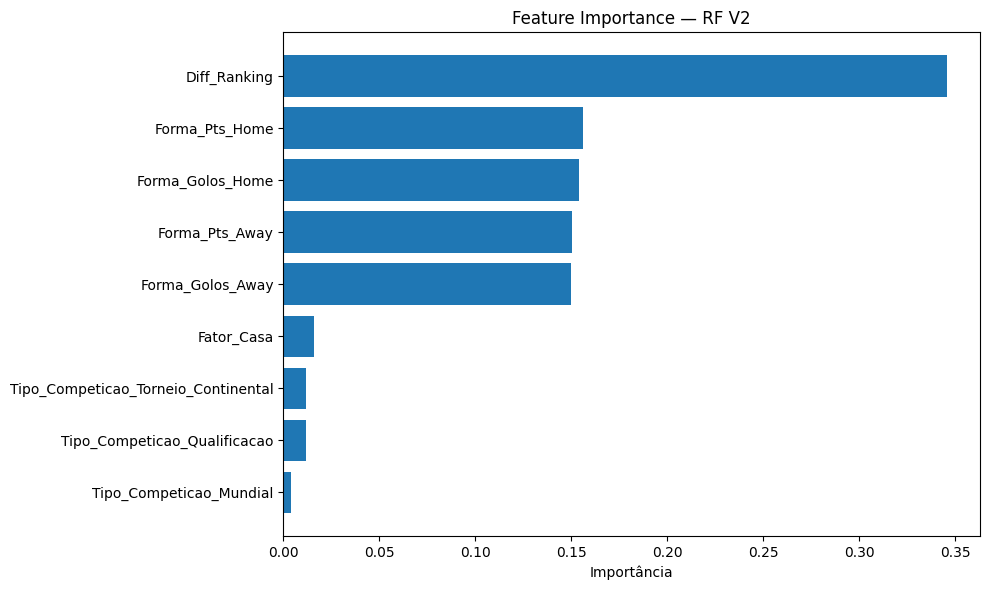

In [ ]:
clf_rf = joblib.load("../models/model_v2_clf_rf.pkl")

# Extrair feature names após o preprocessador
ohe_features = list(
    clf_rf.named_steps["pre"]
    .named_transformers_["ohe"]
    .get_feature_names_out(["Tipo_Competicao"])
)
num_features = [
    "Diff_Ranking", "Fator_Casa", "Forma_Golos_Home",
    "Forma_Pts_Home", "Forma_Golos_Away", "Forma_Pts_Away",
]
all_features = ohe_features + num_features

# Feature importance
importances = clf_rf.named_steps["clf"].feature_importances_
df_imp = pd.DataFrame({
    "feature":    all_features,
    "importance": importances
}).sort_values("importance", ascending=False)

print(df_imp.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1])
ax.set_title("Feature Importance — RF V2")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.show()

Diff_Ranking domina com 34.6% — o ranking FIFA é de longe a feature mais preditiva. Confirma que a decisão de remover amigáveis e o corte em 1990 foi correcta — o modelo aprendeu que o ranking importa em contexto competitivo.

Features de forma equilibradas (~15% cada) — as 4 features de forma têm peso quase idêntico entre si. Isto valida a decisão de ter features separadas (Golos + Pontos) × (Home + Away) — todas contribuem de forma independente.

Fator_Casa apenas 1.6% — baixo porque no dataset de treino a maioria dos jogos tem Fator_Casa=1 (equipa em casa). No Mundial com Fator_Casa=0 forçado, este sinal quase desaparece — o que é correcto.

Tipo_Competicao quase irrelevante (<1.2% cada) — o modelo não diferencia muito entre tipos de competição. Poderia ser candidata a remoção numa iteração futura.